In [ ]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd()
while BASE_DIR != BASE_DIR.parent and not (BASE_DIR / 'src').exists():
    BASE_DIR = BASE_DIR.parent
SRC_DIR = BASE_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from config import OUTPUT_DIR, DATA_DIR

COHORT = 'ANAS'


In [1]:
import pandas as pd 
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations, permutations

import matplotlib.pyplot as plt
import matplotlib 
from scipy.stats import fisher_exact
# import statsmodels.stats.multitest as smt
import seaborn as sns
# from statannotations.Annotator import Annotator
from sklearn.preprocessing import StandardScaler


import os 
from scipy import stats

In [2]:
reduce = ['Raw','PCA2','PCA3','t_SNE','UMAP']
def max_s(data):
    return data[data['silhouette_scores'] == max(data['silhouette_scores'])]

In [3]:
clustering_result = []
for i in reduce:
    print(i)
    ward = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Hclust' / 'ward_silhouette_scores.csv'))
    average = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Hclust' / 'average_silhouette_scores.csv'))
    complete = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Hclust' / 'complete_silhouette_scores.csv'))
    kmeans = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Kmeans' / 'K_silhouette_scores.csv'))
    d1 = pd.concat([max_s(ward),max_s(average),max_s(complete),max_s(kmeans)]).reset_index(drop=True)
    d1['name'] = ['ward','average','complete','kmeans']
    d1['data'] = i
    clustering_result.append(d1)
    print(d1[['name','K','silhouette_scores']])

Raw
       name  K  silhouette_scores
0      ward  3           0.420968
1   average  4           0.424249
2  complete  4           0.240325
3    kmeans  3           0.457180
PCA2
       name  K  silhouette_scores
0      ward  3           0.507248
1   average  4           0.470088
2  complete  4           0.432260
3    kmeans  3           0.522518
PCA3
       name  K  silhouette_scores
0      ward  5           0.332318
1   average  3           0.496398
2  complete  5           0.172247
3    kmeans  3           0.497139
t_SNE
       name  K  silhouette_scores
0      ward  3           0.395815
1   average  3           0.352398
2  complete  3           0.401743
3    kmeans  3           0.418352
UMAP
       name  K  silhouette_scores
0      ward  3           0.386456
1   average  3           0.388819
2  complete  3           0.351000
3    kmeans  3           0.422018


In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 예시 데이터
df = pd.concat(clustering_result)
# 정규화
scaler = MinMaxScaler()
df['silhouette_norm'] = scaler.fit_transform(df[['silhouette_scores']])
df['ssd_norm'] = scaler.fit_transform(np.log10(df[['ssd_scores']]))
df['ssd_norm'] = 1 - df['ssd_norm']  # SSD는 작을수록 좋음 → 반전

# 최종 종합 점수 (동일 가중치)
df['final_score'] = (df['silhouette_norm'] + df['ssd_norm']) / 2

df[['K','data', 'name', 'silhouette_scores', 'ssd_scores', 'final_score']].sort_values(by = 'final_score')

,K,data,name,silhouette_scores,ssd_scores,final_score
2,5,PCA3,complete,0.172247,2.357607e+06,0.179698
1,3,t_SNE,average,0.352398,1.509550e+08,0.257160
2,4,Raw,complete,0.240325,3.666197e+06,0.257804
0,3,t_SNE,ward,0.395815,1.408551e+08,0.322128
2,3,t_SNE,complete,0.401743,1.335068e+08,0.332905
2,3,UMAP,complete,0.351000,1.083757e+07,0.368960
0,3,UMAP,ward,0.386456,1.025988e+07,0.421940
0,5,PCA3,ward,0.332318,1.634967e+06,0.424008
1,3,UMAP,average,0.388819,9.787259e+06,0.427350
1,4,Raw,average,0.424249,6.438336e+06,0.496020


In [5]:
df[['K','data', 'name', 'silhouette_scores', 'ssd_scores', 'final_score']]

,K,data,name,silhouette_scores,ssd_scores,final_score
0,3,Raw,ward,0.420968,4.526767e+06,0.506555
1,4,Raw,average,0.424249,6.438336e+06,0.496020
2,4,Raw,complete,0.240325,3.666197e+06,0.257804
3,3,Raw,kmeans,0.457180,1.953799e+03,0.892987
0,3,PCA2,ward,0.507248,4.113371e+06,0.633854
1,4,PCA2,average,0.470088,4.128593e+06,0.580651
2,4,PCA2,complete,0.432260,2.419654e+06,0.549736
3,3,PCA2,kmeans,0.522518,1.421394e+03,1.000000
0,5,PCA3,ward,0.332318,1.634967e+06,0.424008
1,3,PCA3,average,0.496398,1.237005e+07,0.570798


In [6]:
data = pd.read_csv(str(OUTPUT_DIR / "Clustering" / COHORT / 'PCA2' / 'Kmeans' / 'K_cluster_3_raw_data.csv'"))

data['cluster'].value_counts()

cluster
1    2999
0     797
2     739
Name: count, dtype: int64

In [7]:
def chi_squre(data,feature1, feature2):
    ctab = pd.crosstab(data[feature1],data[feature2])
    stat, p, dof, expected = chi2_contingency(ctab)
    return stat, p,expected

In [8]:
def cate_value_count(data, cate_feature_lst):
    result = pd.DataFrame()
    for feature in cate_feature_lst:
        cate_tmp = pd.DataFrame(data[feature].value_counts())
        cate_tmp.columns =['freq']
        cate_tmp['feature']=feature
        cate_tmp = cate_tmp.reset_index(drop=False)
        cate_tmp.columns = ['index','freq','feature']
        result = pd.concat([result, cate_tmp],axis=0)
    return result

In [9]:
def eGFR_cal(Cr,age, sex):
    if sex == 2 :# 여성
        K = 0.7
        alpha = -0.241 
        last = 1.012
    else:# 남성
        K = 0.9
        alpha = -0.302 
        last = 1
    
    eGFR = 142*((min(Cr/K,1))**alpha)*((max(Cr/K,1))**(-1.2))*((0.9938)**age)*last
    return np.round(eGFR,0)

In [10]:
def mk_eGFR_data(clinical_only_raw):
    eGFR_data = []
    for sample in range(len(clinical_only_raw)):
        eGFR_data.append(eGFR_cal(clinical_only_raw.loc[sample,"Cr"], clinical_only_raw.loc[sample,"age"], clinical_only_raw.loc[sample,"sex"]))
    return eGFR_data

In [11]:
def mkMBP(cli):
    cli['MBP'] = (2*cli['dia'] + cli['sys'])/3
    return cli

In [12]:
raw_data0319 = pd.read_csv('/nfs-data-124/skhan/bds3/시각화모듈/KoGES/Koges_Ansan_Ansung_Urban_Country_SNUH_Gangnam_HTN,LIPID 변경.csv')
raw_data0319['eGFR'] = mk_eGFR_data(raw_data0319)
raw_data0319 = mkMBP(raw_data0319)
raw_data0319.rename(columns = {'sample' : 'dist_id'}, inplace = True)

In [13]:
# insulin 안산안성데이터 
insulin_data = pd.read_csv('/nfs-data-123/skhan/SW1/Koges안산안성_insulin_20250226.csv')
insulin_data.rename(columns = {'sample' : 'dist_id'}, inplace = True)
insulin_data = insulin_data[['dist_id','FINS','HOMA-IR','HOMA-B']]
# raw data와 insulin 안산안성데이터 Merge 
raw_data0319 = pd.merge(raw_data0319, insulin_data).reset_index(drop=True)

In [14]:
# cohort = ['AN','AS','CT','NC']
# cohort = ['NC']
cohort = ['AN','AS']
# cohort = ['CT']
raw_data = pd.DataFrame()
for cohort_name in cohort:
    cohort_data = raw_data0319[raw_data0319['area'] == cohort_name].reset_index()
    raw_data = pd.concat([raw_data, cohort_data]).reset_index(drop=True)

In [15]:
data = pd.read_csv(str(OUTPUT_DIR / "Clustering" / COHORT / 'PCA2' / 'Kmeans' / 'K_cluster_3_raw_data.csv'"))
# data = pd.read_csv(str(OUTPUT_DIR / "Clustering" / COHORT / 'PCA3' / 'Hclust'/average_cluster_3_raw_data.csv"))

try:
    print(len(data['sample']))
except:
    shap = pd.read_csv(DATA_DIR / 'SHAP_total_koges_sample.csv')
    sample = shap['sample']
    data['sample'] = sample.values

data.rename(columns = {'sample' : 'dist_id'}, inplace = True)

if data['cluster'].value_counts()[1]>data['cluster'].value_counts()[0]:
    data=data.replace({'cluster':{1:3,0:1}})
    data=data.replace({'cluster':{3:0}})

data=data.replace({'cluster':{1:3,2:1}})
data=data.replace({'cluster':{3:2}})
data['cluster'].value_counts()

4535


cluster
0    2999
2     797
1     739
Name: count, dtype: int64

In [16]:
data['cluster'].value_counts()

cluster
0    2999
2     797
1     739
Name: count, dtype: int64

In [17]:
# shap_data = pd.read_csv('./shap_with_sample.csv')
# shap_data.columns
# shap_data[np.logical_or(shap_data['area'] == 'AN',shap_data['area'] == 'AS')].reset_index(drop=True).to_csv('./cohort_clustering/ANAS_SHAP.csv',index=False)
# shap_data[shap_data['area'] == 'CT'].reset_index(drop=True).to_csv('./cohort_clustering/CT_SHAP.csv',index=False)
# shap_data[shap_data['area'] == 'NC'].reset_index(drop=True).to_csv('./cohort_clustering/NC_SHAP.csv',index=False)

In [18]:
# raw data + cluster
data = pd.merge(data[['dist_id','cluster']],raw_data).reset_index(drop=True)
data['progress_DM'].value_counts()

progress_DM
0    3708
1     824
Name: count, dtype: int64

In [19]:
data[data['cluster'] == 0]['progress_DM'].value_counts()

progress_DM
0    2799
1     197
Name: count, dtype: int64

In [20]:
data[data['cluster'] == 1]['progress_DM'].value_counts()

progress_DM
0    488
1    251
Name: count, dtype: int64

In [21]:
data[data['cluster'] == 2]['progress_DM'].value_counts()

progress_DM
0    421
1    376
Name: count, dtype: int64

In [22]:
for cluster_name in data['cluster'].sort_values().unique():
    incident_cases = data[data['cluster'] == cluster_name]['progress_DM'].sum()
    
    # 총 person-years
    total_person_years = data[data['cluster'] == cluster_name]['fu_yrs'].sum()
    
    # incident rate 계산
    incident_rate = (incident_cases / total_person_years) * 1000
    
    print(f"cluster{cluster_name+1}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

cluster1: Incident Rate: 17.58 cases per 1,000 person-years
cluster2: Incident Rate: 93.47 cases per 1,000 person-years
cluster3: Incident Rate: 132.95 cases per 1,000 person-years


In [23]:
incident_cases = data['progress_DM'].sum()

# 총 person-years
total_person_years = data['fu_yrs'].sum()

# incident rate 계산
incident_rate = (incident_cases / total_person_years) * 1000

print(f"cluster{cluster_name+1}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

cluster3: Incident Rate: 49.28 cases per 1,000 person-years


In [24]:
# Eluster별 데이터 
C1 = data[data['cluster']==0].reset_index(drop=True)
C2 = data[data['cluster']==1].reset_index(drop=True)
C3 = data[data['cluster']==2].reset_index(drop=True)
# C4 = data[data['cluster']==3].reset_index(drop=True)
data_lst = [C1, C2, C3]
# data_lst = [C1, C2, C3, C4]

In [25]:
P_cluster_lst = ['C1', 'C2', 'C3']#,'C4']

P_combi = list(combinations(P_cluster_lst, 2))
P_combi

[('C1', 'C2'), ('C1', 'C3'), ('C2', 'C3')]

In [26]:
C1['Endotype'] = 'C1'
C2['Endotype'] = 'C2'
C3['Endotype'] = 'C3'
# C4['Endotype'] = 'C4'

In [27]:
pd.options.display.max_rows = 10
total_data = pd.concat(data_lst,axis=0)
total_data = total_data.drop(columns = 'cluster').reset_index(drop=True)
total_data=total_data.replace({'sex':{1:0,2:1}})
total_data

,dist_id,index,progress_DM,area,sex,age,waist,bmi,sys,dia,...,Cr,basedate,enddate,fu_yrs,eGFR,MBP,FINS,HOMA-IR,HOMA-B,Endotype
0,NIH20F9000043,0,0,AN,1,63,75.300000,25.125470,108.0,69.0,...,0.95,2013-06-15,2017-06-15,4.000000,67.0,82.000000,4.7,1.044444,62.666667,C1
1,NIH20F9001664,7,0,AN,0,55,79.200000,19.413601,102.0,69.0,...,0.96,2014-08-15,2018-09-15,4.084873,93.0,80.000000,6.0,1.318519,83.076923,C1
2,NIH20F9002341,9,0,AN,0,62,84.066667,24.208110,105.0,63.0,...,1.18,2014-04-15,2018-05-15,4.082136,70.0,77.000000,6.2,1.408395,76.965517,C1
3,NIH20F9003158,11,0,AN,1,62,74.300000,24.138910,118.0,80.0,...,0.98,2013-08-15,2017-04-15,3.665982,65.0,92.666667,10.0,2.049383,180.000000,C1
4,NIH20F9003567,13,0,AN,0,56,88.300000,23.494409,129.0,81.0,...,0.95,2008-09-15,2012-04-15,3.581109,94.0,97.000000,9.8,2.250370,117.600000,C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4527,NIH20F9828473,6740,1,AS,0,65,94.600000,24.705882,125.0,82.0,...,0.94,2006-09-15,2010-07-15,3.830253,90.0,96.333333,10.1,2.668395,82.636364,C3
4528,NIH20F9847141,6752,1,AS,1,52,90.833333,25.198832,136.0,81.0,...,0.71,2006-05-15,2008-06-15,2.086242,102.0,99.333333,12.2,3.283457,95.478261,C3
4529,NIH20F9888362,6779,1,AS,1,55,85.900000,24.432333,150.0,86.0,...,0.88,2013-10-15,2017-09-15,3.917864,78.0,107.333333,11.0,3.177778,73.333333,C3
4530,NIH20F9906831,6792,1,AS,1,68,90.133333,25.390219,150.0,79.0,...,0.70,2001-10-15,2003-06-15,1.664613,94.0,102.666667,10.9,2.906667,87.200000,C3


In [28]:
color_map_dict = {
    'C1': '#FF0000',  #  빨간색
    'C2': '#0000FF',  # 파란색
    'C3': '#008000',  # 초록색
   # 'C4':'#800080',  #  보라색
#    'E5': '#FFFF00',  # 노란색 / 핑크색 FFC0CB
#     'E6': '#FFC0CB', 
#       'E7': '#FFA500'
#     'E8': '#00CED1'
}

In [29]:
# 관심 변수 
# conti_feature_lst =['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT','eGFR','FINS','HOMA-IR','HOMA-B']
# conti_feature_lst =['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT']#,'FINS','HOMA-IR','HOMA-B']
conti_feature_lst =['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT','FINS','HOMA-IR','HOMA-B']
cate_feature_lst = ['sex','DM_FH','exercise','smoke','drink','htndiag','lipdiag']
# conti_feature_lst =['age','bmi','waist','FBS','Hba1c','Tg']#,'FINS','HOMA-IR','HOMA-B']

In [30]:
variables_lst = ['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT','FINS','HOMA-IR','HOMA-B','sex','DM_FH','exercise','smoke','drink','htndiag','lipdiag','progress_DM']

In [31]:
def convert_units(df):
    """
    FBS, HbA1c, TG 단위를 mg/dL → mmol/L, % → mmol/mol 로 변환합니다.
    단위 변환:
      - FBS: mg/dL × 0.0555 = mmol/L
      - TG: mg/dL × 0.0113 = mmol/L
      - HbA1c: % × 10.929 + 23.5 = mmol/mol
    """
    df_converted = df.copy()

    # FBS 변환
    if 'FBS' in df_converted.columns:
        df_converted['FBS'] = df_converted['FBS'] * 0.0555

    # TG 변환
    if 'Tg' in df_converted.columns:
        df_converted['Tg'] = df_converted['Tg'] * 0.0113

    # HbA1c 변환
    if 'Hba1c' in df_converted.columns:
        df_converted['Hba1c'] = df_converted['Hba1c'] * 10.929 + 23.5

    return df_converted

In [32]:
import tableone
BC_data = data.copy()
BC_data = convert_units(BC_data)
BC_data=BC_data.replace({'sex':{1:'M',2:'F'},
                          'DM_FH':{0:'No',1:'Yes'},
                          'exercise':{0.:'Never',1.:'Light',2.:'Regular'},
                          'smoke':{0.:'Never',1.:'Ex',2.:'Now'},
                          'drink':{0:'Never',1.:'Ex',2.:'Now'},
                          'progress_DM':{0:'No',1:'Yes'},
                          'htndiag':{0:'No',1:'Yes'},
                          'lipdiag':{0:'No',1:'Yes'}})

order = {
    'smoke':    ['Never', 'Ex', 'Now'],
    'drink':    ['Never', 'Ex', 'Now'],
    'exercise': ['Never', 'Light', 'Regular'],
    # 필요하면 다른 범주 변수도 여기에 추가
}

# variables_lst = BC_data.columns.tolist()[1:]
groupby='cluster'
#groupby='progress_DM'
mytable=tableone.TableOne(BC_data,columns=variables_lst,
                          categorical=cate_feature_lst+['progress_DM'],
                          continuous=conti_feature_lst,
                          groupby=groupby,
                          pval=True,
                          order=order)
pd.set_option('display.max_rows',None)
mytable

Grouped by cluster                                                               
                                      Missing       Overall             0             1            2 P-Value
n                                                      4532          2996           739          797        
age, mean (SD)                              0    61.2 (8.4)    61.1 (8.1)    62.4 (9.0)   60.2 (8.8)  <0.001
bmi, mean (SD)                              0    24.4 (3.1)    23.9 (2.9)    25.3 (3.1)   25.5 (3.0)  <0.001
waist, mean (SD)                            0    85.2 (8.8)    83.7 (8.8)    87.6 (8.6)   88.7 (7.9)  <0.001
FBS, mean (SD)                              0     5.1 (0.5)     4.9 (0.4)     5.1 (0.3)    5.9 (0.4)  <0.001
Hba1c, mean (SD)                            0    84.4 (3.9)    82.4 (2.8)    89.2 (1.9)   87.7 (2.7)  <0.001
MBP, mean (SD)                              0   91.8 (11.1)   90.6 (11.1)   92.9 (11.1)  95.2 (10.6)  <0.001
Tg, mean (SD)                               0     1.6 (1.1)     1.4 (0.9)     1.8 (1.2)    1.9 (1.4)  <0.001
WBC, mean (SD)                              0     5.4 (1.6)     5.2 (1.5)     6.0 (1.6)    5.9 (1.7)  <0.001
ALT, mean (SD)                              0   23.1 (12.7)   21.4 (10.4)   25.4 (14.6)  27.3 (16.5)  <0.001
FINS, mean (SD)                             0     7.4 (4.3)     7.2 (4.5)     7.8 (3.6)    7.8 (4.0)  <0.001
HOMA-IR, mean (SD)                          0     1.7 (1.0)     1.6 (1.0)     1.8 (0.8)    2.1 (1.1)  <0.001
HOMA-B, mean (SD)                           0  101.8 (73.1)  111.8 (81.2)  100.6 (53.9)  65.3 (34.7)  <0.001
sex, n (%)         F                            2408 (53.1)   1608 (53.7)    457 (61.8)   343 (43.0)  <0.001
                   M                            2124 (46.9)   1388 (46.3)    282 (38.2)   454 (57.0)        
DM_FH, n (%)       No                           4448 (98.1)   2958 (98.7)    714 (96.6)   776 (97.4)  <0.001
                   Yes                             84 (1.9)      38 (1.3)      25 (3.4)     21 (2.6)        
exercise, n (%)    Never                        2826 (62.4)   1788 (59.7)    534 (72.3)   504 (63.2)  <0.001
                   Light                         492 (10.9)    342 (11.4)      57 (7.7)    93 (11.7)        
                   Regular                      1214 (26.8)    866 (28.9)    148 (20.0)   200 (25.1)        
smoke, n (%)       Never                        2865 (63.2)   1956 (65.3)    501 (67.8)   408 (51.2)  <0.001
                   Ex                           1016 (22.4)    660 (22.0)    123 (16.6)   233 (29.2)        
                   Now                           651 (14.4)    380 (12.7)    115 (15.6)   156 (19.6)        
drink, n (%)       Never                        2237 (49.4)   1492 (49.8)    440 (59.5)   305 (38.3)  <0.001
                   Ex                             313 (6.9)     207 (6.9)      54 (7.3)     52 (6.5)        
                   Now                          1982 (43.7)   1297 (43.3)    245 (33.2)   440 (55.2)        
htndiag, n (%)     No                           2658 (58.6)   1901 (63.5)    386 (52.2)   371 (46.5)  <0.001
                   Yes                          1874 (41.4)   1095 (36.5)    353 (47.8)   426 (53.5)        
lipdiag, n (%)     No                           1701 (37.5)   1278 (42.7)    171 (23.1)   252 (31.6)  <0.001
                   Yes                          2831 (62.5)   1718 (57.3)    568 (76.9)   545 (68.4)        
progress_DM, n (%) No                           3708 (81.8)   2799 (93.4)    488 (66.0)   421 (52.8)  <0.001
                   Yes                           824 (18.2)     197 (6.6)    251 (34.0)   376 (47.2)

In [33]:
# import tableone
# BC_data = data.copy()
# BC_data=BC_data.replace({'sex':{1:'M',2:'F'},
#                           'DM_FH':{0:'No',1:'Yes'},
#                           'exercise':{0.:'Never',1.:'Light',2.:'Regular'},
#                           'smoke':{0.:'Never',1.:'Ex',2.:'Now'},
#                           'drink':{0:'Never',1.:'Ex',2.:'Now'},
#                           'progress_DM':{0:'No',1:'Yes'},
#                           'htndiag':{0:'No',1:'Yes'},
#                           'lipdiag':{0:'No',1:'Yes'}})

# variables_lst = BC_data.columns.tolist()[1:]
# # groupby='cluster'
# groupby='progress_DM'
# mytable=tableone.TableOne(BC_data,columns=variables_lst,categorical=cate_feature_lst+['progress_DM'],continuous=conti_feature_lst,groupby=groupby,pval=True)
# pd.set_option('display.max_rows',None)
# mytable

In [34]:
pre_diabetes = total_data[np.logical_or(np.logical_and(total_data['FBS']>=100,total_data['FBS']<=125),np.logical_and(total_data['Hba1c']>=5.7,total_data['Hba1c']<=6.4))].reset_index(drop=True)

In [35]:
pre_diabetes[pre_diabetes['Endotype'] == 'C1']['progress_DM'].value_counts()

progress_DM
0    535
1     68
Name: count, dtype: int64

In [36]:
pre_diabetes[pre_diabetes['Endotype'] == 'C2']['progress_DM'].value_counts()

progress_DM
0    488
1    251
Name: count, dtype: int64

In [37]:
pre_diabetes[pre_diabetes['Endotype'] == 'C3']['progress_DM'].value_counts()

progress_DM
0    414
1    376
Name: count, dtype: int64

In [38]:
for cluster_name in pre_diabetes['Endotype'].sort_values().unique():
    incident_cases = pre_diabetes[pre_diabetes['Endotype'] == cluster_name]['progress_DM'].sum()
    
    # 총 person-years
    total_person_years = pre_diabetes[pre_diabetes['Endotype'] == cluster_name]['fu_yrs'].sum()
    
    # incident rate 계산
    incident_rate = (incident_cases / total_person_years) * 1000
    
    print(f"cluster {cluster_name}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

cluster C1: Incident Rate: 30.61 cases per 1,000 person-years
cluster C2: Incident Rate: 93.47 cases per 1,000 person-years
cluster C3: Incident Rate: 134.25 cases per 1,000 person-years


In [39]:
incident_cases = pre_diabetes['progress_DM'].sum()

# 총 person-years
total_person_years = pre_diabetes['fu_yrs'].sum()

# incident rate 계산
incident_rate = (incident_cases / total_person_years) * 1000

print(f"cluster{cluster_name}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

clusterC3: Incident Rate: 90.17 cases per 1,000 person-years


In [40]:
total_data[total_data['Endotype'] == 'C1']['FBS'].mean()

88.1188251001335

In [41]:
total_data[total_data['Endotype'] == 'C2']['FBS'].mean()

92.09878213802436

In [42]:
total_data[total_data['Endotype'] == 'C3']['FBS'].mean()

106.92471769134254

In [43]:
color_map_dict

{'C1': '#FF0000', 'C2': '#0000FF', 'C3': '#008000'}

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C1 vs. C2: t-test independent samples, P_val:1.878e-04 t=-3.739e+00
C2 vs. C3: t-test independent samples, P_val:2.365e-06 t=4.737e+00
C1 vs. C3: t-test independent samples, P_val:7.690e-03 t=2.667e+00
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C1 vs. C2: t-test independent samples, P_val:2.627e-29 t=-1.134e+01
C2 vs. C3: t-test independent samples, P_val:2.625e-01 t=-1.121e+00
C1 vs. C3: t-test independent samples, P_val:2.188e-39 t=-1.328e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C1 vs. C2: t-test independent samples, P_val:2.846e

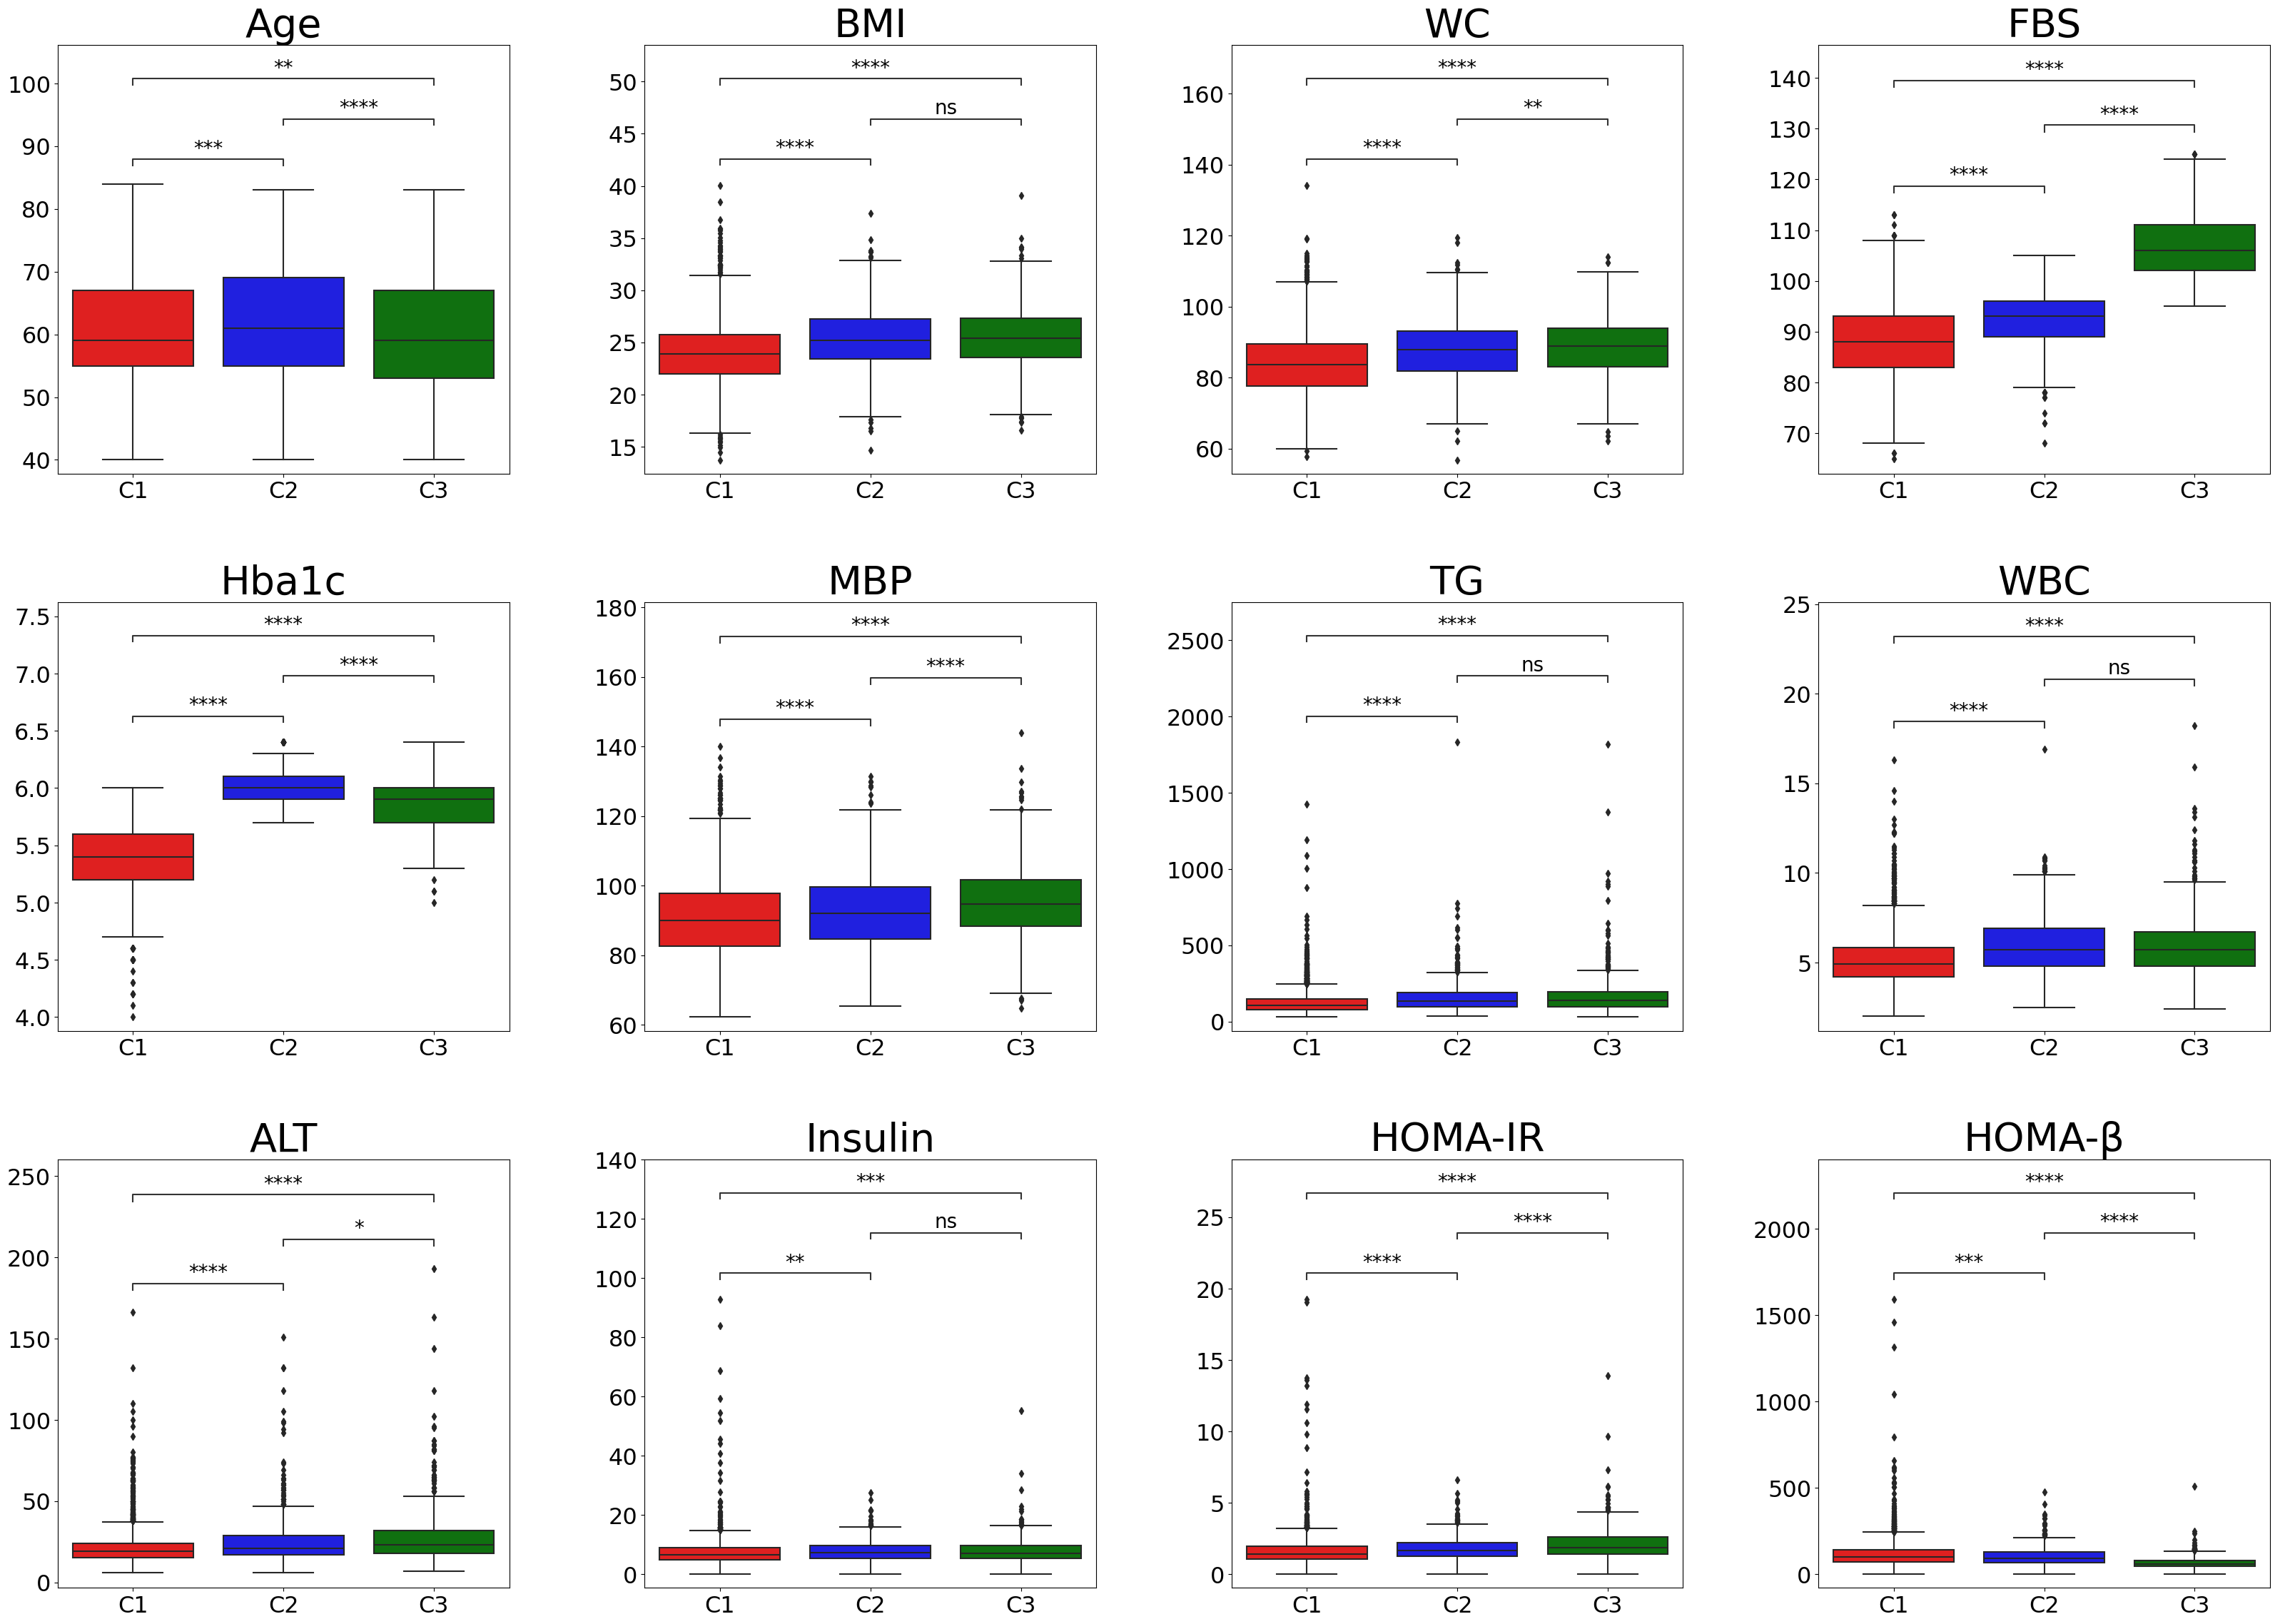

In [51]:
from statannotations.Annotator import Annotator

feature_name = {
    'age': 'Age', 'bmi': 'BMI', 'waist': 'WC', 'sys': 'SBP', 'dia': 'DBP', 'Tg': 'TG',
    'FINS': r'Insulin', 'HOMA-IR': 'HOMA-IR', 'HOMA-B': 'HOMA-β'
}

fig = plt.figure(figsize=(40, 23))
ax1 = fig.add_subplot(111)

for i, FEATURE in enumerate(conti_feature_lst, start=1):
    x = 'Endotype'
    y = FEATURE

    plt.subplot(3, 4, i)
    ax = sns.boxplot(x=x, y=y, data=total_data, palette=color_map_dict)
    ax.set(xlabel=None, ylabel=None)

    # Annotator 객체 사용
    annotator = Annotator(ax, P_combi, data=total_data, x=x, y=y)
    annotator.configure(
        test='t-test_ind',
        text_format='star',
        loc='inside',
        fontsize=20,
        comparisons_correction=None
    )
    annotator.apply_and_annotate()

    # Annotation 글씨 크기 조정
    for text in ax.texts:
        text.set_fontsize(20)

    # title 설정
    title_name = feature_name.get(FEATURE, FEATURE)
    plt.title(title_name, fontsize=40)

    plt.rc('xtick', labelsize=23)
    plt.rc('ytick', labelsize=23)

plt.subplots_adjust(wspace=0.3, hspace=0.3, top=0.99, bottom=0.05)

# 전체 figure 설정
ax1.spines['top'].set_color('none')
ax1.spines['bottom'].set_color('none')
ax1.spines['left'].set_color('none')
ax1.spines['right'].set_color('none')
ax1.tick_params(labelcolor='w', top=False, bottom=False, left=False, right=False)

# 저장
# fig.savefig("./Clustering_분석결과/continuous_features_box_graph_total_0529.png",
#             dpi=300, bbox_inches='tight', transparent=True, format='png')
plt.show()

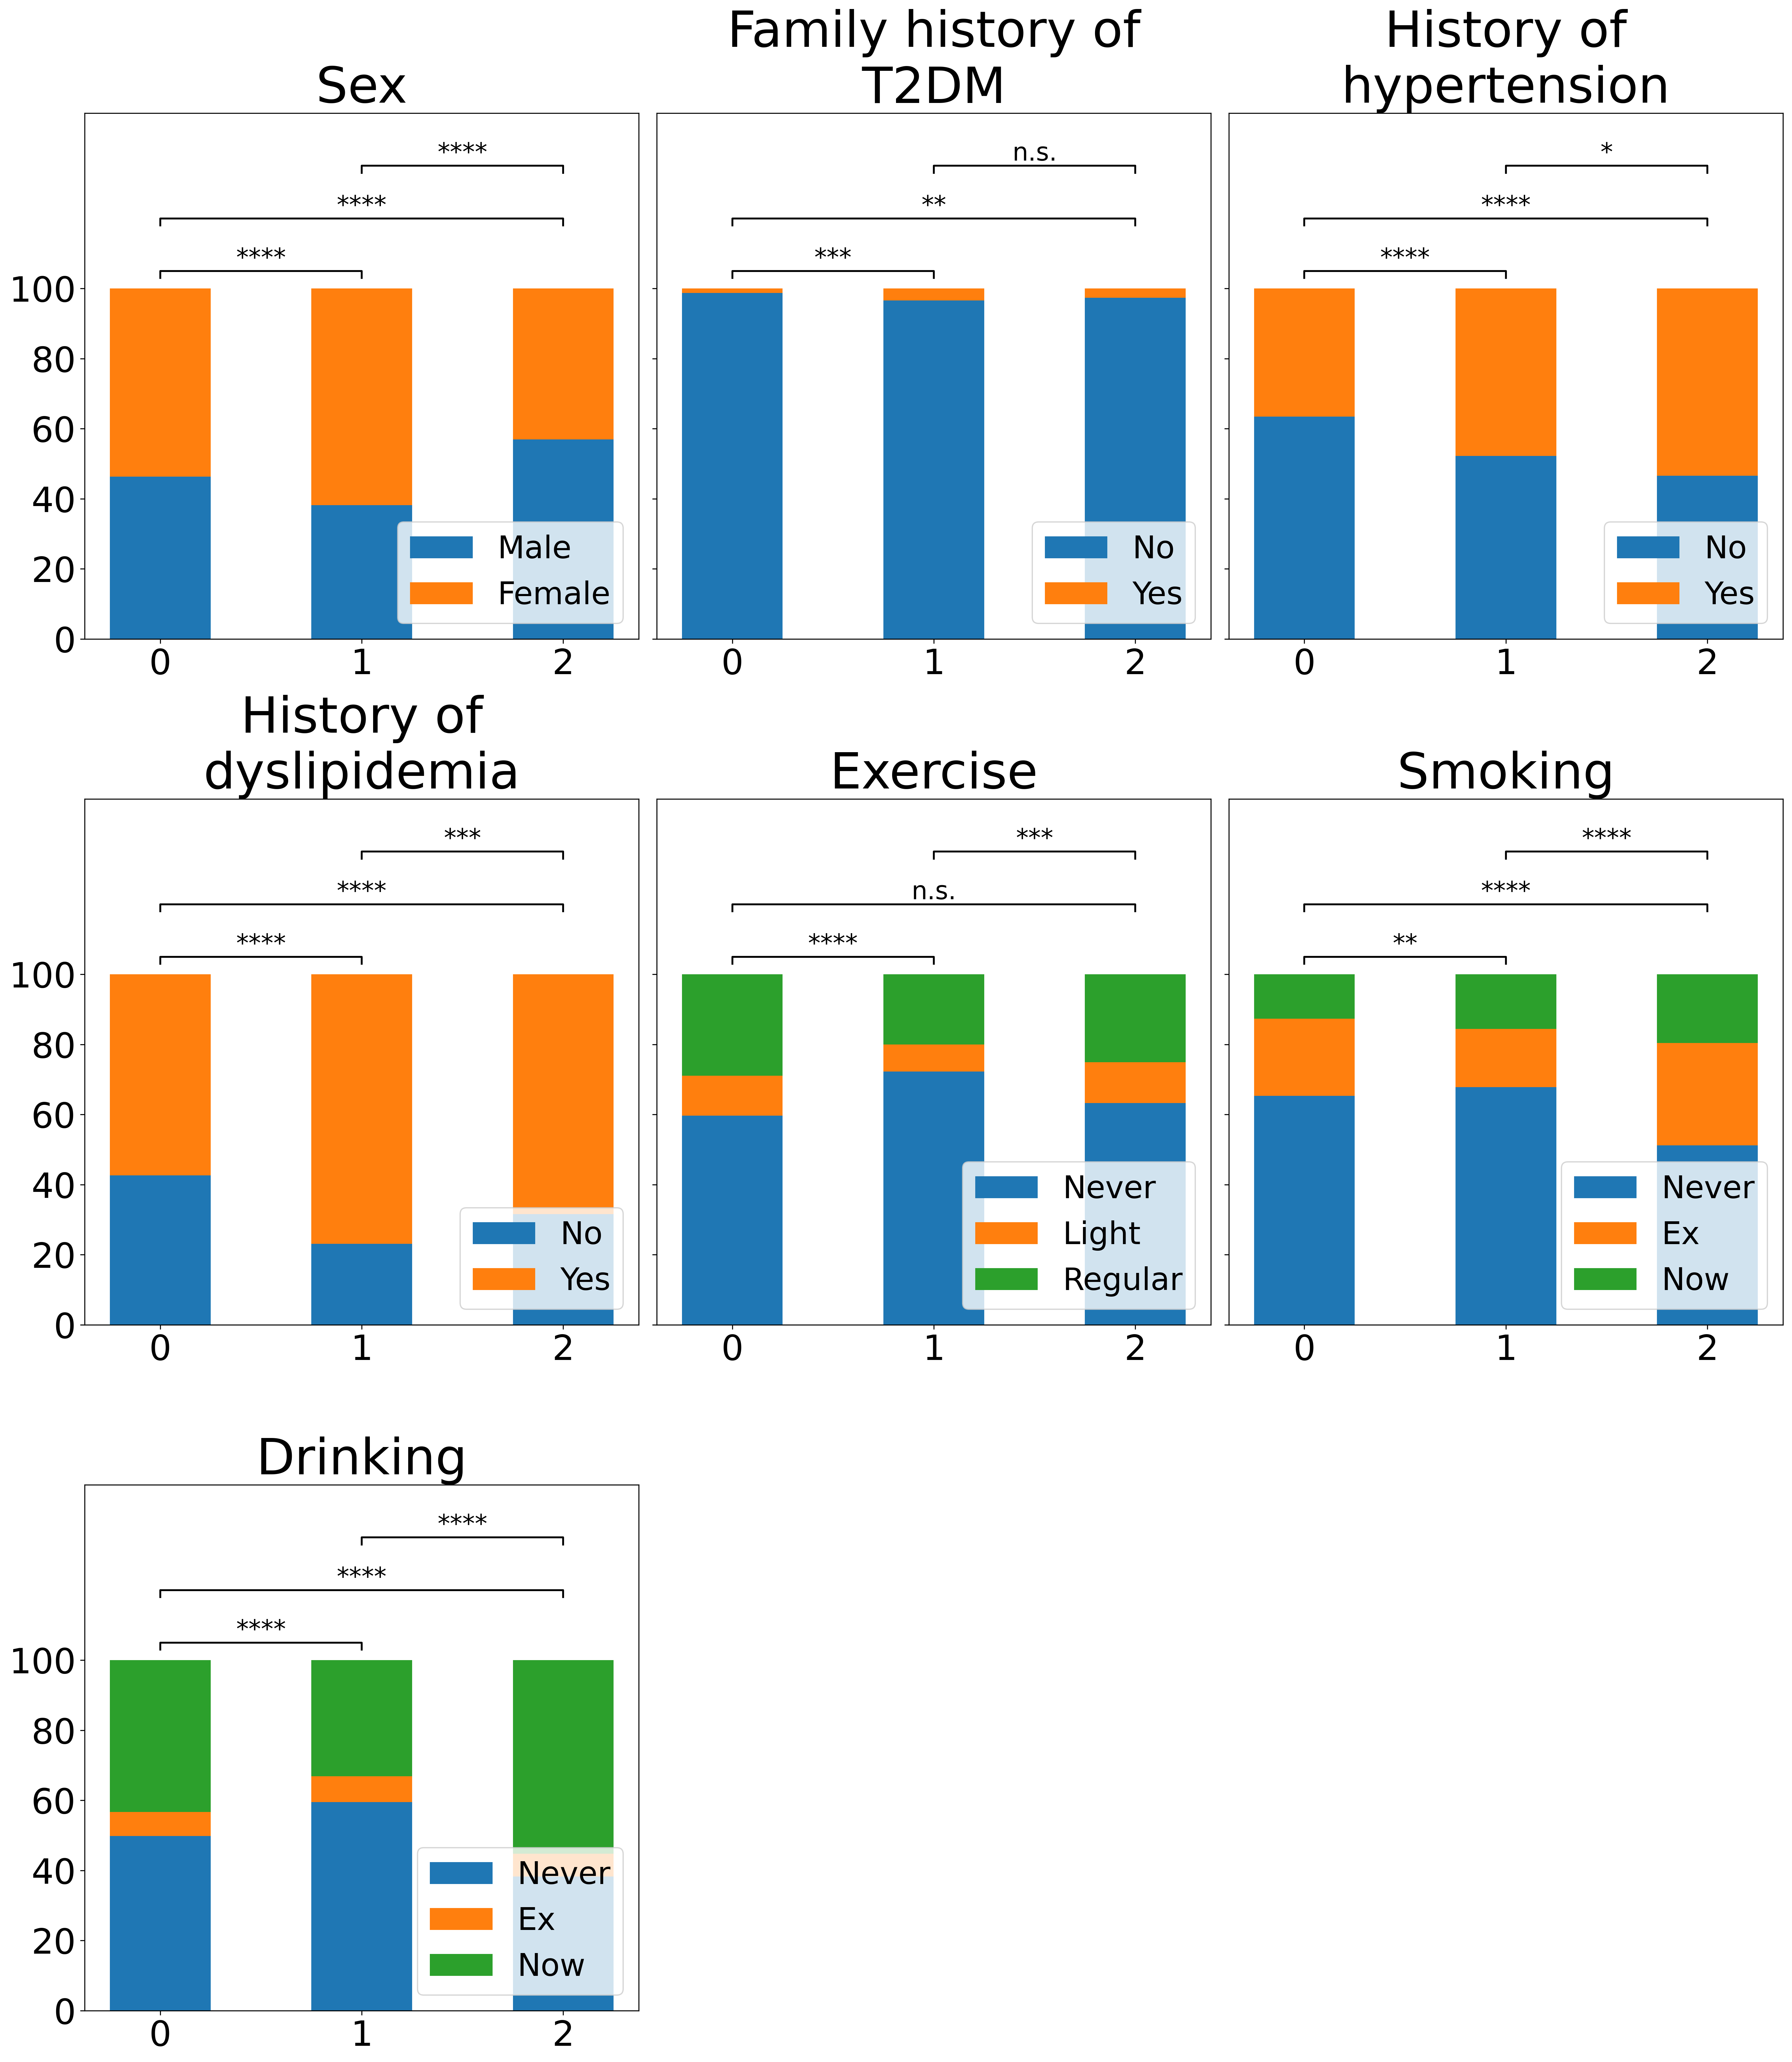

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import chi2_contingency

# --- 데이터 복사 ---
df = data.copy()
group_var = 'cluster'
categorical_vars = ['sex', 'DM_FH', 'htndiag', 'lipdiag', 'exercise', 'smoke', 'drink']
# categorical_vars = ['sex', 'DM_FH', 'htndiag', 'lipdiag']

# 범주 순서
category_orders = {
    'sex': ['Male', 'Female'],
    'DM_FH': ['No', 'Yes'],
    'exercise': ['Never', 'Light', 'Regular'],
    'smoke': ['Never', 'Ex', 'Now'],
    'drink': ['Never', 'Ex', 'Now'],
    'progress_DM': ['No', 'Yes'],
    'htndiag': ['No', 'Yes'],
    'lipdiag': ['No', 'Yes']
}

# 숫자 → 문자열 변환
df = df.replace({
    'sex': {1: 'Male', 2: 'Female'},
    'DM_FH': {0: 'No', 1: 'Yes'},
    'exercise': {0.: 'Never', 1.: 'Light', 2.: 'Regular'},
    'smoke': {0.: 'Never', 1.: 'Ex', 2.: 'Now'},
    'drink': {0: 'Never', 1: 'Ex', 2: 'Now'},
    'progress_DM': {0: 'No', 1: 'Yes'},
    'htndiag': {0: 'No', 1: 'Yes'},
    'lipdiag': {0: 'No', 1: 'Yes'}
})

title_lst = ['Sex', 'Family history of\nT2DM', 'History of\nhypertension', 'History of\ndyslipidemia',
             'Exercise', 'Smoking', 'Drinking']

# 별표 변환 함수
def get_pvalue_stars(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.001:
        return "**"
    elif p > 0.0001:
        return "***"
    else:
        return "****"

# 그래프 생성
n_vars = len(categorical_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20), sharey=True, dpi=300)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10), sharey=True, dpi=300)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 23), sharey=True, dpi=300)
axes = axes.flatten()

for i, cat_var in enumerate(categorical_vars):
    ax = axes[i]
    count_data = pd.crosstab(df[group_var], df[cat_var])

    # 카테고리 순서 적용
    if cat_var in category_orders:
        valid_categories = [cat for cat in category_orders[cat_var] if cat in count_data.columns]
        count_data = count_data[valid_categories]

    percent_data = count_data.div(count_data.sum(axis=1), axis=0) * 100
    bottoms = np.zeros(len(percent_data.index))
    bar_width = 0.5

    for category in percent_data.columns:
        heights = percent_data[category].values
        ax.bar(percent_data.index, heights, bottom=bottoms, label=category, width=bar_width)
        bottoms += heights

    ax.set_title(title_lst[i], fontsize=40)
    ax.set_ylim(0, 150)
    ax.tick_params(axis='y', labelsize=28)
    ax.tick_params(axis='x', labelsize=28)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.legend(loc='lower right', fontsize=25)

    # --- 카이제곱 검정 및 유의성 표시 ---
    groups = list(count_data.index)
    if len(groups) > 1:
        # 각 그룹쌍 조합에 대해 개별적으로 유의성 표시
        pairs = list(combinations(groups, 2))
        for j, (g1, g2) in enumerate(pairs):
            # 2xN contingency table 생성
            g1_vals = df[df[group_var] == g1][cat_var]
            g2_vals = df[df[group_var] == g2][cat_var]
            categories = np.union1d(g1_vals.unique(), g2_vals.unique())
            g1_counts = [np.count_nonzero(g1_vals == cat) for cat in categories]
            g2_counts = [np.count_nonzero(g2_vals == cat) for cat in categories]
            contingency = np.array([g1_counts, g2_counts])
            chi2, p, _, _ = chi2_contingency(contingency)
            stars = get_pvalue_stars(p)

            # 막대 위치 계산
            x1 = groups.index(g1)
            x2 = groups.index(g2)
            x1_center = x1  # x1 + x_offset 도 가능
            x2_center = x2
            x_center = (x1_center + x2_center) / 2
            height = bottoms.max() + 5 + j * 15  # 가장 높은 막대 위로 일정 간격

            ax.plot([x1_center, x1_center, x2_center, x2_center],
                [height - 2, height, height, height - 2],
                lw=1.5, color='black')

            ax.text(x_center, height, stars, ha='center', va='bottom', fontsize=20)


    else:
        ax.text(0.5, 0.5, "단일 그룹 - 검정 없음", ha='center', va='center', transform=ax.transAxes)

# 남은 subplot 숨기기
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
# plt.savefig("./Clustering_분석결과/categorical_features_box_graph_total_0529.png", dpi=300, bbox_inches='tight', transparent=True, format='png')
plt.show()

In [46]:
# SNP data
#5493
SNP_data_AN_AS = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/anas_snp_110.csv')
SNP_data_AN_AS.rename(columns = {'sample' : 'dist_id'}, inplace = True)
#66798
SNP_data_CT_NC = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/dn_snp_110.csv')
SNP_data_CT_NC.rename(columns = {'sample' : 'dist_id'}, inplace = True)
#965
SNP_data_SNUH1 = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/snuh_2349_snp_110.csv')
SNP_data_SNUH1.rename(columns = {'sample' : 'dist_id'}, inplace = True)
#4106
SNP_data_SNUH2 = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/snuh_8000_snp_110.csv')
SNP_data_SNUH1.rename(columns = {'sample' : 'dist_id'}, inplace = True)

In [47]:
# SNP data + cluster
ANAS_SNP_data = pd.merge(data[['dist_id','cluster']],SNP_data_AN_AS).reset_index(drop=True)
CTNC_SNP_data = pd.merge(data[['dist_id','cluster']],SNP_data_CT_NC).reset_index(drop=True)
SNP_data = pd.concat([ANAS_SNP_data,CTNC_SNP_data],axis=0).reset_index(drop=True)

In [48]:
SNP_lst = [col for col in SNP_data.columns if col.startswith("rs")]

In [49]:
# SciPy의 chi-square로 직접 계산한 p-value
chi2_results = []
for snp in SNP_lst:
    contingency_table = pd.crosstab(SNP_data['cluster'], SNP_data[snp])
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    chi2_results.append({"SNP": snp, "Chi-square": chi2_stat, "SciPy P-Value": p_value})

chi2_df = pd.DataFrame(chi2_results).set_index("SNP")
chi2_df

,Chi-square,SciPy P-Value
SNP,,
rs16826069,4.124005,0.389484
rs2296172,2.817000,0.588902
rs2296173,2.825636,0.587416
rs17106184,4.976475,0.289720
rs3176466,5.739760,0.219444
rs72906810,6.511773,0.164050
rs7531962,2.134235,0.711086
rs10305745,7.330400,0.119425
rs12041243,6.731291,0.150788


In [ ]:
# FDR 
import statsmodels.stats.multitest as smm

# SciPy P-Value 추출
p_values = chi2_df["SciPy P-Value"]
# Benjamini-Hochberg (BH) FDR 보정 적용
rejected, fdr_p_values = smm.fdrcorrection(p_values, alpha=0.05, method='indep')
# FDR 결과를 chi2_df에 추가
chi2_df["FDR Adjusted P-Value"] = fdr_p_values
chi2_df[chi2_df['FDR Adjusted P-Value']<0.001]

In [ ]:
SNP_lst = chi2_df[chi2_df['FDR Adjusted P-Value']<0.001].index.tolist()

In [ ]:
groupby='cluster'
#groupby='progress_DM'

mytable=tableone.TableOne(SNP_data,columns=SNP_lst,categorical=SNP_lst,groupby=groupby,pval=True)
pd.set_option('display.max_rows',None)
mytable